**Student1:** Hammani Abdeslem

**Student2:** Moussous Billel

# Advanced Machine Learning — Lab3
## Deep Reinforcement Learning: DQN & Policy Gradients

> **Module:** Machine Learning under Real-World Constraints  
> **Phase:** Phase 1 — Temporal Adaptation  
> **Duration:** 2 hours  
> **Prerequisites:** Week 2 (Q-Learning, MDPs)

---

## Learning Objectives

By the end of this lab you will be able to:
1. Explain why tabular Q-Learning fails on large state spaces
2. Implement a **Deep Q-Network (DQN)** with Experience Replay and Target Network
3. Implement **REINFORCE** (Monte-Carlo Policy Gradient)
4. Train both agents on **CartPole-v1**
5. Compare DQN and REINFORCE in terms of stability and sample efficiency
6. Understand the role of each DQN trick through ablation

---

##  Theoretical Recap

### From Tabular Q-Learning to DQN

In Week 2, we stored Q-values in a table of size $|\mathcal{S}| \times |\mathcal{A}|$.  
This breaks down when states are continuous or high-dimensional (e.g. pixels).

**Solution:** Approximate $Q(s,a)$ with a neural network:
$$Q(s,a;\theta) \approx Q^*(s,a)$$

The network takes state $s$ as input and outputs Q-values for all actions.

### DQN Loss Function

We minimise the Mean Squared TD Error:
$$\mathcal{L}(\theta) = \mathbb{E}\left[\left(\underbrace{r + \gamma \max_{a'} Q(s',a';\theta^-)}_{\text{TD target}} - Q(s,a;\theta)\right)^2\right]$$

where $\theta^-$ are the **frozen target network** parameters.

### Two Key Tricks in DQN

| Trick | Problem it solves | How |
|-------|------------------|-----|
| **Experience Replay** | Correlated consecutive samples break SGD | Store transitions, sample mini-batches randomly |
| **Target Network** | Moving targets cause divergence | Use frozen copy $\theta^-$, update every $C$ steps |

### Policy Gradient — REINFORCE

Instead of learning a value function, directly optimise the policy $\pi_\theta$:
$$\nabla_\theta J(\theta) = \mathbb{E}_\pi\left[\sum_t \nabla_\theta \log \pi_\theta(a_t|s_t) \cdot G_t\right]$$

where $G_t = \sum_{k=t}^{T} \gamma^{k-t} r_k$ is the return from step $t$.

**Intuition:** Increase probability of actions that led to high return.

---

## Part 0 — Setup & Imports

In [9]:
# Uncomment on Google Colab if needed
# !pip install -q gymnasium tensorflow numpy matplotlib

import numpy as np
import random
import collections
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import gymnasium as gym

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__)
print('Gymnasium: ', gym.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
Gymnasium:  1.2.3
GPU available: []


---
## Part 1 — CartPole Environment

**CartPole-v1** is the classic RL benchmark:
- A pole is attached to a cart on a frictionless track
- Goal: keep the pole upright by pushing left or right

**State** (4 continuous values):
| Index | Variable | Range |
|-------|----------|-------|
| 0 | Cart position | \[-4.8, 4.8\] |
| 1 | Cart velocity | \(-\infty, +\infty\) |
| 2 | Pole angle | \[-0.418, 0.418\] rad |
| 3 | Pole angular velocity | \(-\infty, +\infty\) |

**Action space:** {0 = push left, 1 = push right}  
**Reward:** +1 for every step the pole stays up  
**Done:** pole angle > 12° or cart out of bounds  
**Success:** average reward ≥ 475 over 100 episodes  

### Why can't we use tabular Q-Learning here?
The state is a vector of 4 **continuous** values → infinite state space → table is impossible.

Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
  Shape: (4,)
  Low:  [-4.8               -inf -0.41887903        -inf]
  High: [4.8               inf 0.41887903        inf]

Action space: Discrete(2)
  n = 2 (0=left, 1=right)

Random policy: survived 11 steps, total reward = 11.0


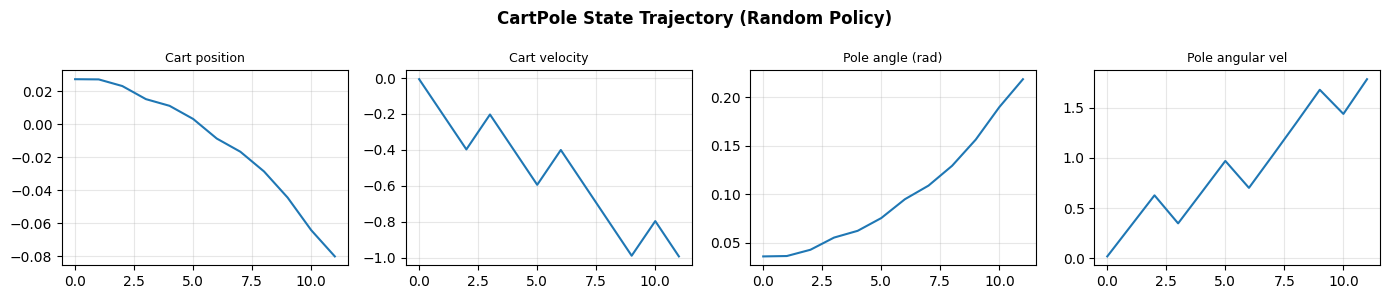

In [2]:
# Create and explore CartPole environment
env = gym.make('CartPole-v1')

print('Observation space:', env.observation_space)
print('  Shape:', env.observation_space.shape)
print('  Low: ', env.observation_space.low)
print('  High:', env.observation_space.high)
print()
print('Action space:', env.action_space)
print('  n =', env.action_space.n, '(0=left, 1=right)')

# Run one random episode to observe dynamics
obs, _ = env.reset(seed=SEED)
total_reward = 0
trajectory = [obs.copy()]

for step in range(200):
    action = env.action_space.sample()   # random policy
    obs, reward, terminated, truncated, _ = env.step(action)
    total_reward += reward
    trajectory.append(obs.copy())
    if terminated or truncated:
        break

print(f'\nRandom policy: survived {step+1} steps, total reward = {total_reward}')

# Visualise pole angle over time
traj = np.array(trajectory)
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
labels = ['Cart position', 'Cart velocity', 'Pole angle (rad)', 'Pole angular vel']
for i, (ax, lbl) in enumerate(zip(axes, labels)):
    ax.plot(traj[:, i])
    ax.set_title(lbl, fontsize=9)
    ax.grid(True, alpha=0.3)
plt.suptitle('CartPole State Trajectory (Random Policy)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Exercise 1 — Understanding the State Space

**Q1.** Why is tabular Q-Learning impossible for CartPole?  
**Q2.** Suppose we discretise each state dimension into 10 bins. How many total states would the table have?  
**Q3.** What would the DQN input and output dimensions be for CartPole?  
**Q4.** A random policy survives ~10-20 steps. What score would a good policy achieve? Why 475 and not 500?

In [4]:
# --- Exercise 1 — YOUR ANSWERS HERE ---

# Q1: Why is tabular Q-Learning impossible for CartPole?
print("Q1: Tabular Q-Learning is impossible because the state space consists of 4 continuous variables. This creates an infinite number of possible states, making it impossible to store them in a finite Q-Table.")

# Q2: Number of states after discretisation
bins_per_dim = 10
n_dims = 4
n_states_discretised = bins_per_dim ** n_dims
print(f'Q2: Discretised state space size = {n_states_discretised:,}')

# Q3: DQN dimensions
input_dim  = 4    # state dimension
output_dim = 2    # number of actions
print(f'Q3: DQN input = {input_dim}, output = {output_dim}')

# Q4: Why 475 and not 500?
print("Q4: The max score is 500. The threshold is 475 (averaged over 100 episodes) to allow for occasional early failures or slightly unlucky starting states, while still proving the agent has fundamentally learned the balancing policy.")

Q1: Tabular Q-Learning is impossible because the state space consists of 4 continuous variables. This creates an infinite number of possible states, making it impossible to store them in a finite Q-Table.
Q2: Discretised state space size = 10,000
Q3: DQN input = 4, output = 2
Q4: The max score is 500. The threshold is 475 (averaged over 100 episodes) to allow for occasional early failures or slightly unlucky starting states, while still proving the agent has fundamentally learned the balancing policy.


---
## Part 2 — Experience Replay Buffer

**Problem with online learning:**  
Consecutive transitions $(s_t, a_t, r_t, s_{t+1})$ are highly correlated → SGD assumption violated.

**Solution:** Store transitions in a circular buffer of capacity $N$.  
At each update, sample a random mini-batch of size $B$.

```
Buffer (capacity N):   [t₁, t₂, t₃, ..., tₙ]
                              ↕ random sample ↕
Mini-batch (size B):   [t₅, t₁₂, t₃, t₉₉, ...]   → gradient update
```

This **decorrelates** samples and reuses past experience.

In [5]:
class ReplayBuffer:
    """
    Circular experience replay buffer.

    Stores transitions (s, a, r, s', done) and allows
    random mini-batch sampling for DQN training.
    """

    def __init__(self, capacity=10_000):
        """
        Args:
            capacity: Maximum number of transitions to store.
                        Oldest entries are overwritten when full.
        """
        self.buffer = collections.deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        """Store one transition."""
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        """
        Sample a random mini-batch.

        Returns:
            Tuple of numpy arrays: (states, actions, rewards, next_states, dones)
        """
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            np.array(states,      dtype=np.float32),
            np.array(actions,     dtype=np.int32),
            np.array(rewards,     dtype=np.float32),
            np.array(next_states, dtype=np.float32),
            np.array(dones,       dtype=np.float32),
        )

    def __len__(self):
        return len(self.buffer)

# Quick test
buf = ReplayBuffer(capacity=100)
for _ in range(50):
    s  = np.random.randn(4)
    a  = np.random.randint(2)
    r  = np.random.randn()
    s2 = np.random.randn(4)
    d  = False
    buf.push(s, a, r, s2, d)

states, actions, rewards, next_states, dones = buf.sample(8)
print('Buffer size:', len(buf))
print('Sampled batch shapes:')
print('  states:     ', states.shape)
print('  actions:    ', actions.shape)
print('  rewards:    ', rewards.shape)
print('  next_states:', next_states.shape)
print('ReplayBuffer working correctly')

Buffer size: 50
Sampled batch shapes:
  states:      (8, 4)
  actions:     (8,)
  rewards:     (8,)
  next_states: (8, 4)
ReplayBuffer working correctly


---
## Part 3 — DQN Network Architecture

We build a simple MLP that maps states to Q-values:

```
Input  [4]  →  Dense(64, ReLU)  →  Dense(64, ReLU)  →  Output [2]
```

We maintain **two identical networks**:
- `online_network`: trained at every step
- `target_network`: frozen copy, updated every `C` steps

**Why a target network?**  
Without it, the TD target $r + \gamma\max_{a'}Q(s',a';\theta)$ changes at every gradient step → the network chases a moving target → training diverges.

In [7]:
def build_dqn(state_dim, n_actions, hidden_units=64):
    """
    Build a simple DQN (MLP).

    Args:
        state_dim  : int — dimension of state vector
        n_actions  : int — number of discrete actions
        hidden_units: int — neurons per hidden layer

    Returns:
        model: Keras Model  input=(batch, state_dim), output=(batch, n_actions)
    """
    state_dim = int(state_dim)
    n_actions = int(n_actions)
    
    model = keras.Sequential([
        layers.Input(shape=(state_dim,)),
        layers.Dense(hidden_units, activation='relu',
                        kernel_initializer='he_normal'),
        layers.Dense(hidden_units, activation='relu',
                        kernel_initializer='he_normal'),
        layers.Dense(n_actions,    activation='linear'),   # No activation on output!
    ], name='DQN')
    return model

# Instantiate and inspect
STATE_DIM = env.observation_space.shape[0]   # 4
N_ACTIONS  = env.action_space.n              # 2

online_net = build_dqn(STATE_DIM, N_ACTIONS)
target_net = build_dqn(STATE_DIM, N_ACTIONS)

# Synchronise weights
target_net.set_weights(online_net.get_weights())

online_net.summary()

# Test forward pass
dummy_state = np.random.randn(1, STATE_DIM).astype(np.float32)
q_vals = online_net(dummy_state)
print('Q-values for dummy state:', q_vals.numpy())
print('Greedy action:', np.argmax(q_vals.numpy()))

Model: "DQN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,610 (18.01 KB)

 Trainable params: 4,610 (18.01 KB)

 Non-trainable params: 0 (0.00 B)

Q-values for dummy state: [[-2.232437   -0.39653194]]
Greedy action: 1


### Exercise 2 — Why Linear Output Activation?

**Q1.** Why do we use `activation='linear'` (i.e. no activation) on the output layer?  
**Q2.** Why do we use `activation='relu'` on hidden layers and not `sigmoid`?  
**Q3.** The target network and online network start with the same weights. How often should we synchronise them? What happens if we sync too frequently? Too rarely?  
**Q4.** In the DQN loss, why do we not propagate gradients through the target network?

In [18]:
# --- Exercise 2 — YOUR WRITTEN ANSWERS ---

# Q1:
print("Q1: Q-values represent expected future cumulative rewards,\n which can be any continuous real number (e.g., 500).\n If we used activations like sigmoid or softmax,\n it would artificially squash the outputs to [0, 1],\n preventing the network from predicting the true reward values.\n Linear activation allows unbounded outputs.")
print("_" * 100)
# Q2:
print("Q2: ReLU prevents the vanishing gradient problem,\n which is very common with sigmoid activations.\n Because RL data is noisy and unstable, we need strong,\n healthy gradients to train the network efficiently.\n ReLU allows for much faster and more reliable convergence.")
print("_" * 100)
# Q3:
print("Q3: We usually sync them every C steps (e.g., 100-1000).\n If we sync too frequently, the target moves too much,\n bringing back the instability we tried to fix.\n If we sync too rarely, the target network provides stale,\n outdated Q-value estimates, which drastically slows down the agent's learning.")
print("_" * 100)
# Q4:
print("Q4: The target network's output is meant to act as a fixed,\n constant 'ground truth' for the current update step.\n If we propagated gradients through it, we would be mathematically \n changing the target while trying to optimize towards it,\n completely defeating the purpose of having a frozen target.")

Q1: Q-values represent expected future cumulative rewards,
 which can be any continuous real number (e.g., 500).
 If we used activations like sigmoid or softmax,
 it would artificially squash the outputs to [0, 1],
 preventing the network from predicting the true reward values.
 Linear activation allows unbounded outputs.
____________________________________________________________________________________________________
Q2: ReLU prevents the vanishing gradient problem,
 which is very common with sigmoid activations.
 Because RL data is noisy and unstable, we need strong,
 healthy gradients to train the network efficiently.
 ReLU allows for much faster and more reliable convergence.
____________________________________________________________________________________________________
Q3: We usually sync them every C steps (e.g., 100-1000).
 If we sync too frequently, the target moves too much,
 bringing back the instability we tried to fix.
 If we sync too rarely, the target network prov

---
## Part 4 — DQN Agent

We now implement the full DQN agent.  
The training loop follows the original Mnih et al. (2015) algorithm:

```
For each step:
  1. ε-greedy action selection using online_net
  2. Store (s, a, r, s', done) in replay buffer
  3. If buffer ≥ batch_size:
       a. Sample mini-batch
       b. Compute TD targets using target_net
       c. Gradient step on online_net
  4. Every C steps: target_net ← online_net
  5. Decay ε
```

In [19]:
class DQNAgent:
    """
    Deep Q-Network agent (Mnih et al., 2015).

    Key components:
      - Online network  : learns at every step
      - Target network  : frozen copy, stabilises training
      - Replay buffer   : breaks temporal correlations
      - ε-greedy policy : balances exploration vs exploitation
    """

    def __init__(
        self,
        state_dim,
        n_actions,
        lr=1e-3,
        gamma=0.99,
        epsilon=1.0,
        epsilon_min=0.01,
        epsilon_decay=0.995,
        buffer_capacity=10_000,
        batch_size=64,
        target_update_freq=100,
    ):
        self.state_dim   = state_dim
        self.n_actions   = n_actions
        self.gamma       = gamma
        self.epsilon     = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.batch_size  = batch_size
        self.target_update_freq = target_update_freq
        self.step_count  = 0

        # Networks
        self.online_net = build_dqn(state_dim, n_actions)
        self.target_net = build_dqn(state_dim, n_actions)
        self.target_net.set_weights(self.online_net.get_weights())

        # Optimiser
        self.optimiser = keras.optimizers.Adam(learning_rate=lr)

        # Replay buffer
        self.replay_buffer = ReplayBuffer(capacity=buffer_capacity)

        # Logging
        self.losses = []

    # ----------------------------------------------------------
    def select_action(self, state, mode='train'):
        """
        ε-greedy action selection.

        Args:
            state : numpy array (state_dim,)
            mode  : 'train' (with ε) or 'eval' (greedy)
        Returns:
            action: int
        """
        if mode == 'train' and np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)
        state_t = tf.convert_to_tensor(state[np.newaxis], dtype=tf.float32)
        q_vals  = self.online_net(state_t, training=False)
        return int(tf.argmax(q_vals[0]).numpy())

    # ----------------------------------------------------------
    @tf.function
    def _train_step(self, states, actions, rewards, next_states, dones):
        """
        One gradient update step.

        Loss = MSE(TD_target - Q(s,a;θ))
        where TD_target = r + γ·max_{a'} Q(s',a'; θ⁻)
        """
        # --- TD targets (no gradient through target_net) ---
        next_q    = self.target_net(next_states, training=False)   # (B, A)
        max_next_q = tf.reduce_max(next_q, axis=1)                  # (B,)
        td_targets = rewards + self.gamma * max_next_q * (1.0 - dones)  # (B,)

        # --- Online network gradient ---
        with tf.GradientTape() as tape:
            q_all  = self.online_net(states, training=True)         # (B, A)
            # Pick Q-value for the action actually taken
            action_idx = tf.stack(
                [tf.range(tf.shape(actions)[0]), actions], axis=1
            )
            q_taken = tf.gather_nd(q_all, action_idx)               # (B,)
            loss = tf.reduce_mean(tf.square(td_targets - q_taken))

        grads = tape.gradient(loss, self.online_net.trainable_variables)
        self.optimiser.apply_gradients(
            zip(grads, self.online_net.trainable_variables)
        )
        return loss

    # ----------------------------------------------------------
    def train_step(self, state, action, reward, next_state, done):
        """Store transition and maybe update networks."""
        self.replay_buffer.push(state, action, reward, next_state, done)
        self.step_count += 1

        if len(self.replay_buffer) < self.batch_size:
            return  # Not enough samples yet

        # Sample and train
        states, actions, rewards, next_states, dones = \
            self.replay_buffer.sample(self.batch_size)

        loss = self._train_step(
            tf.constant(states),
            tf.constant(actions),
            tf.constant(rewards),
            tf.constant(next_states),
            tf.constant(dones),
        )
        self.losses.append(float(loss))

        # Sync target network
        if self.step_count % self.target_update_freq == 0:
            self.target_net.set_weights(self.online_net.get_weights())

        # Decay exploration
        self.epsilon = max(self.epsilon_min,
                           self.epsilon * self.epsilon_decay)

print('DQNAgent class defined')

DQNAgent class defined


---
## Part 5 — Training the DQN

We now run the training loop.  
**Expected results:** CartPole solved (score ≥ 475) within ~300–500 episodes.

In [20]:
def run_dqn_training(n_episodes=500, print_every=50):
    """Full DQN training loop on CartPole-v1."""

    train_env = gym.make('CartPole-v1')
    agent = DQNAgent(
        state_dim   = train_env.observation_space.shape[0],
        n_actions   = train_env.action_space.n,
        lr          = 1e-3,
        gamma       = 0.99,
        epsilon     = 1.0,
        epsilon_min = 0.01,
        epsilon_decay = 0.995,
        buffer_capacity = 10_000,
        batch_size  = 64,
        target_update_freq = 100,
    )

    episode_rewards = []

    for ep in range(n_episodes):
        state, _ = train_env.reset()
        ep_reward = 0

        while True:
            action = agent.select_action(state, mode='train')
            next_state, reward, terminated, truncated, _ = train_env.step(action)
            done = terminated or truncated

            agent.train_step(state, action, reward, next_state, float(done))

            state      = next_state
            ep_reward += reward

            if done:
                break

        episode_rewards.append(ep_reward)

        if (ep + 1) % print_every == 0:
            avg = np.mean(episode_rewards[-100:])
            print(f'Ep {ep+1:4d} | Avg(100)={avg:6.1f} | ε={agent.epsilon:.3f} '
                    f'| Buffer={len(agent.replay_buffer):5d}')

    train_env.close()
    return agent, episode_rewards


print('Training DQN on CartPole-v1 ...')
print('=' * 60)
dqn_agent, dqn_rewards = run_dqn_training(n_episodes=500)

Training DQN on CartPole-v1 ...
Ep   50 | Avg(100)=  19.5 | ε=0.010 | Buffer=  975
Ep  100 | Avg(100)= 134.0 | ε=0.010 | Buffer=10000
Ep  150 | Avg(100)= 265.1 | ε=0.010 | Buffer=10000
Ep  200 | Avg(100)= 311.4 | ε=0.010 | Buffer=10000
Ep  250 | Avg(100)= 384.3 | ε=0.010 | Buffer=10000
Ep  300 | Avg(100)= 445.4 | ε=0.010 | Buffer=10000
Ep  350 | Avg(100)= 364.3 | ε=0.010 | Buffer=10000
Ep  400 | Avg(100)= 321.5 | ε=0.010 | Buffer=10000
Ep  450 | Avg(100)= 401.0 | ε=0.010 | Buffer=10000
Ep  500 | Avg(100)= 307.9 | ε=0.010 | Buffer=10000


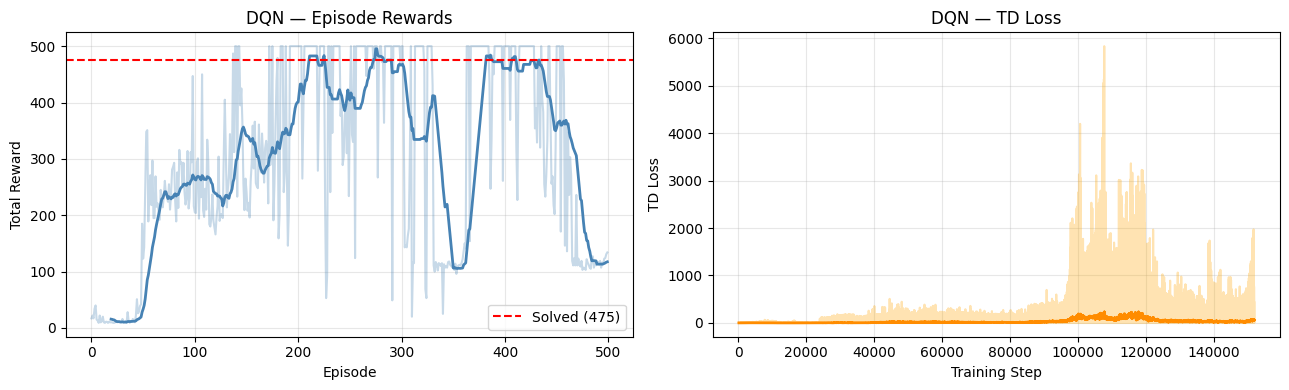

In [21]:
# --- Plot DQN learning curve ---
def smooth(x, w=20):
    return np.convolve(x, np.ones(w)/w, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(dqn_rewards, alpha=0.3, color='steelblue')
ax.plot(range(19, len(dqn_rewards)), smooth(dqn_rewards, 20),
        color='steelblue', linewidth=2)
ax.axhline(475, color='red', linestyle='--', label='Solved (475)')
ax.set_xlabel('Episode'); ax.set_ylabel('Total Reward')
ax.set_title('DQN — Episode Rewards'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
if dqn_agent.losses:
    ax.plot(dqn_agent.losses, alpha=0.3, color='orange')
    if len(dqn_agent.losses) > 200:
        ax.plot(range(199, len(dqn_agent.losses)),
                smooth(dqn_agent.losses, 200),
                color='darkorange', linewidth=2)
ax.set_xlabel('Training Step'); ax.set_ylabel('TD Loss')
ax.set_title('DQN — TD Loss'); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('dqn_training.png', dpi=150, bbox_inches='tight')
plt.show()

### Exercise 3 — Ablation Study

The two key DQN tricks are **Experience Replay** and **Target Network**.  
Let's measure their individual impact.

**Task:** Complete the function `run_ablation` that trains a DQN variant by disabling one trick at a time.

| Variant | Replay Buffer | Target Network |
|---------|--------------|----------------|
| Full DQN | ✅ | ✅ |
| No target net | ✅ | ❌ (online = target) |
| No replay | ❌ (batch=1) | ✅ |

Running ablation study (3 variants × 300 episodes) ...
This may take a few minutes.
Variant A done
Variant B done


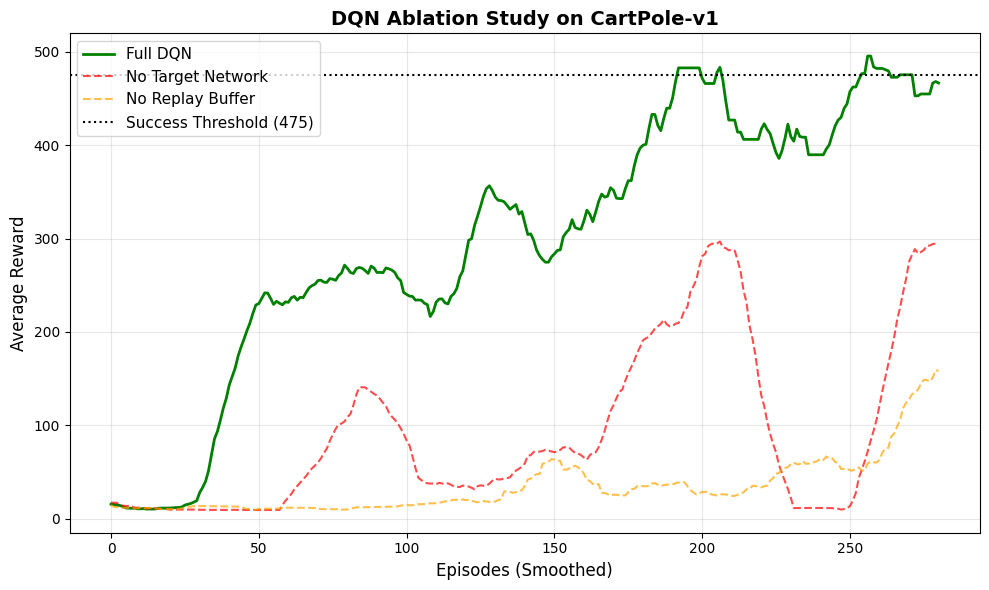


--- Ablation Conclusion ---
1. Full DQN: Learns smoothly and climbs toward the maximum score.
2. No Target Network: The learning is unstable. It might learn a little, but often crashes or fluctuates wildly because the network is chasing a moving target.
3. No Replay Buffer: Fails completely. Because the data is correlated, the agent overfits to recent states and forgets how to balance, staying near a score of 10-20.


In [25]:
def run_ablation(use_replay=True, use_target_net=True, n_episodes=300):
    """
    Train DQN with specific components enabled/disabled.

    Args:
        use_replay      : if False, use batch_size=1 (no replay)
        use_target_net  : if False, sync target every step (same as online)
        n_episodes      : training episodes

    Returns:
        rewards list
    """
    abl_env = gym.make('CartPole-v1')

    agent = DQNAgent(
        state_dim   = abl_env.observation_space.shape[0],
        n_actions   = abl_env.action_space.n,
        batch_size  = 64 if use_replay else 1,
        target_update_freq = 100 if use_target_net else 1,  # sync every step if disabled
    )

    rewards = []

    for ep in range(n_episodes):
        state, _ = abl_env.reset()
        ep_r = 0
        while True:
            action = agent.select_action(state, mode='train')
            ns, r, term, trunc, _ = abl_env.step(action)
            done = term or trunc
            agent.train_step(state, action, r, ns, float(done))
            state = ns; ep_r += r
            if done: break
        rewards.append(ep_r)

    abl_env.close()
    return rewards


print('Running ablation study (3 variants × 300 episodes) ...')
print('This may take a few minutes.')

# --- TODO: run and store results for each variant ---

# Full DQN (already have dqn_rewards)

# Variant A: no target network
rewards_no_target = run_ablation(use_replay=True,  use_target_net=False, n_episodes=300)
print('Variant A done')

# Variant B: no experience replay
rewards_no_replay = run_ablation(use_replay=False, use_target_net=True,  n_episodes=300)
print('Variant B done')

# --- TODO: plot and compare the three curves ---
# Helper function to smooth the curves using a moving average
def moving_average(data, window_size=20):
    """Calculates the moving average to smooth out the noisy RL reward plots."""
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

plt.figure(figsize=(10, 6))

# Plot Full DQN (we use the first 300 episodes to match the ablation length)
plt.plot(moving_average(dqn_rewards[:300]), label='Full DQN', color='green', linewidth=2)

# Plot Variant A
plt.plot(moving_average(rewards_no_target), label='No Target Network', color='red', alpha=0.7, linestyle='--')

# Plot Variant B
plt.plot(moving_average(rewards_no_replay), label='No Replay Buffer', color='orange', alpha=0.7, linestyle='--')

plt.title('DQN Ablation Study on CartPole-v1', fontsize=14, fontweight='bold')
plt.xlabel('Episodes (Smoothed)', fontsize=12)
plt.ylabel('Average Reward', fontsize=12)
plt.axhline(y=475, color='black', linestyle=':', label='Success Threshold (475)')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Print the theoretical conclusion ---
print("\n--- Ablation Conclusion ---")
print("1. Full DQN: Learns smoothly and climbs toward the maximum score.")
print("2. No Target Network: The learning is unstable. It might learn a little, but often crashes or fluctuates wildly because the network is chasing a moving target.")
print("3. No Replay Buffer: Fails completely. Because the data is correlated, the agent overfits to recent states and forgets how to balance, staying near a score of 10-20.")


---
## Part 6 — REINFORCE (Policy Gradient)

**Key idea:** Instead of learning Q-values, directly parameterise the policy:
$$\pi_\theta(a|s) = \text{softmax}(\text{network}(s))$$

**Policy Gradient Theorem:**
$$\nabla_\theta J(\theta) = \mathbb{E}_\pi\left[\nabla_\theta \log \pi_\theta(a_t|s_t) \cdot G_t\right]$$

**REINFORCE algorithm:**
1. Run full episode, collect $(s_0,a_0,r_0,\ldots,s_T)$
2. Compute returns $G_t = \sum_{k=t}^T \gamma^{k-t} r_k$
3. Update: $\theta \leftarrow \theta + \alpha \sum_t \nabla_\theta \log\pi_\theta(a_t|s_t)\cdot G_t$

**Note:** REINFORCE is **on-policy** and uses Monte-Carlo returns (not TD).

### Variance Reduction — Baseline

Raw returns $G_t$ have high variance → slow learning.  
We subtract a **baseline** $b$ (often mean return):
$$\nabla_\theta J = \mathbb{E}\left[\nabla_\theta \log \pi_\theta(a_t|s_t) \cdot (G_t - b)\right]$$

This does **not** introduce bias (the baseline is independent of action).

In [17]:
def build_policy_net(state_dim, n_actions, hidden=64):
    """
    Policy network: maps state -> action probabilities.
    Output uses softmax so probabilities sum to 1.
    """
    model = keras.Sequential([
        layers.Input(shape=(state_dim,)),
        layers.Dense(hidden, activation='relu'),
        layers.Dense(hidden, activation='relu'),
        layers.Dense(n_actions, activation='softmax'),  # probabilities!
    ], name='PolicyNet')
    return model


class REINFORCEAgent:
    """
    Monte-Carlo Policy Gradient (Williams, 1992).
    Collects full episodes, then performs one gradient update.
    """

    def __init__(self, state_dim, n_actions, lr=1e-3, gamma=0.99, use_baseline=True):
        self.gamma        = gamma
        self.use_baseline = use_baseline
        self.policy       = build_policy_net(state_dim, n_actions)
        self.optimiser    = keras.optimizers.Adam(lr)
        self.episode_rewards = []

    def select_action(self, state):
        """
        Sample action from current policy distribution.
        Returns action (int) and its log probability.
        """
        state_t = tf.convert_to_tensor(state[np.newaxis], dtype=tf.float32)
        probs   = self.policy(state_t, training=False)[0]  # (n_actions,)
        action  = np.random.choice(len(probs), p=probs.numpy())
        return action

    def compute_returns(self, rewards):
        """
        Compute discounted returns from a list of step rewards.

        G_t = r_t + γ·r_{t+1} + γ²·r_{t+2} + ...

        Args:
            rewards: list of floats (length T)
        Returns:
            returns: numpy array (length T)
        """
        returns = np.zeros(len(rewards))
        G = 0.0
        for t in reversed(range(len(rewards))):
            G = rewards[t] + self.gamma * G
            returns[t] = G
        return returns

    def update(self, states, actions, rewards):
        """
        Policy gradient update after one complete episode.

        Loss = -Σ_t log π(a_t|s_t) · (G_t - baseline)
        """
        returns = self.compute_returns(rewards)

        if self.use_baseline:
            returns = returns - np.mean(returns)  # subtract mean baseline

        returns = tf.constant(returns, dtype=tf.float32)
        states  = tf.constant(np.array(states), dtype=tf.float32)
        actions = tf.constant(actions, dtype=tf.int32)

        with tf.GradientTape() as tape:
            probs     = self.policy(states, training=True)          # (T, A)
            log_probs = tf.math.log(probs + 1e-8)                   # (T, A)
            # Select log_prob of the action taken
            idx       = tf.stack([tf.range(tf.shape(actions)[0]), actions], axis=1)
            chosen_lp = tf.gather_nd(log_probs, idx)                # (T,)
            # Policy gradient loss (negative because we gradient-ASCENT on J)
            loss      = -tf.reduce_mean(chosen_lp * returns)

        grads = tape.gradient(loss, self.policy.trainable_variables)
        self.optimiser.apply_gradients(
            zip(grads, self.policy.trainable_variables)
        )
        return float(loss)

print('REINFORCEAgent class defined')

REINFORCEAgent class defined


In [29]:
def run_reinforce_training(n_episodes=600, print_every=100):
    """Full REINFORCE training loop on CartPole-v1."""

    pg_env   = gym.make('CartPole-v1')
    pg_agent = REINFORCEAgent(
        state_dim = int(pg_env.observation_space.shape[0]),
        n_actions = int(pg_env.action_space.n),
        lr=2e-3, gamma=0.99, use_baseline=True,
    )
    rewards_hist = []
    loss_hist    = []

    for ep in range(n_episodes):
        state, _ = pg_env.reset()
        ep_states, ep_actions, ep_rewards = [], [], []

        # --- Collect one episode ---
        while True:
            action = pg_agent.select_action(state)
            ns, r, term, trunc, _ = pg_env.step(action)
            ep_states.append(state)
            ep_actions.append(action)
            ep_rewards.append(r)
            state = ns
            if term or trunc:
                break

        # --- One gradient update ---
        loss = pg_agent.update(ep_states, ep_actions, ep_rewards)

        rewards_hist.append(sum(ep_rewards))
        loss_hist.append(loss)

        if (ep + 1) % print_every == 0:
            avg = np.mean(rewards_hist[-100:])
            print(f'Ep {ep+1:4d} | Avg(100)={avg:6.1f} | Loss={loss:.4f}')

    pg_env.close()
    return pg_agent, rewards_hist, loss_hist


print('Training REINFORCE on CartPole-v1 ...')
pg_agent, pg_rewards, pg_losses = run_reinforce_training(n_episodes=600)

Training REINFORCE on CartPole-v1 ...
Ep  100 | Avg(100)=  73.4 | Loss=0.7643
Ep  200 | Avg(100)= 324.9 | Loss=0.4647
Ep  300 | Avg(100)= 467.3 | Loss=0.1421
Ep  400 | Avg(100)= 494.5 | Loss=-0.3901
Ep  500 | Avg(100)=  95.8 | Loss=-1.1219
Ep  600 | Avg(100)= 117.2 | Loss=0.5498


---
## Part 7 — DQN vs REINFORCE Comparison

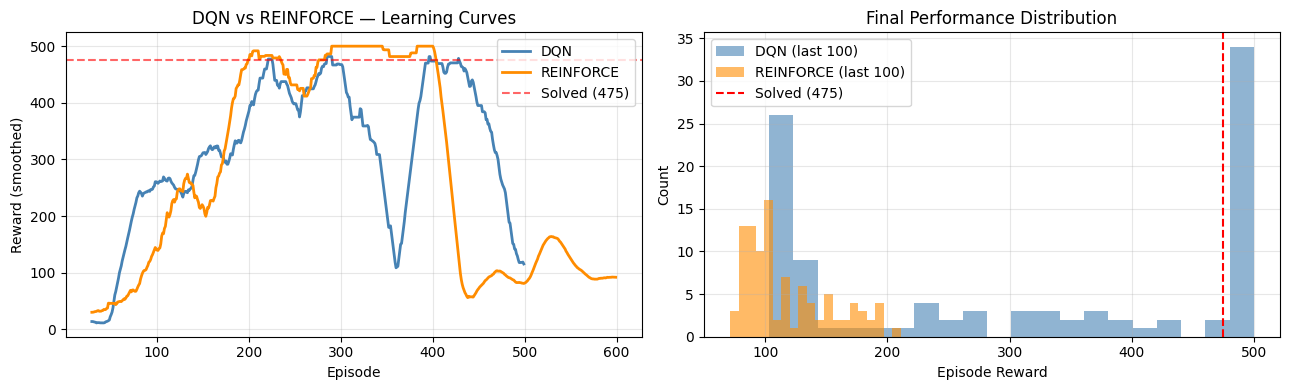


COMPARISON SUMMARY
Method             Avg last 100   Max reward
---------------------------------------------
DQN                       307.9          500
REINFORCE                 117.2          500


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- Learning curves ---
ax = axes[0]
w = 30
ax.plot(range(w-1, len(dqn_rewards)), smooth(dqn_rewards, w),
        label='DQN', linewidth=2, color='steelblue')
ax.plot(range(w-1, len(pg_rewards)), smooth(pg_rewards,  w),
        label='REINFORCE', linewidth=2, color='darkorange')
ax.axhline(475, color='red', linestyle='--', alpha=0.6, label='Solved (475)')
ax.set_xlabel('Episode'); ax.set_ylabel('Reward (smoothed)')
ax.set_title('DQN vs REINFORCE — Learning Curves')
ax.legend(); ax.grid(True, alpha=0.3)

# --- Final performance distribution ---
ax = axes[1]
ax.hist(dqn_rewards[-100:], bins=20, alpha=0.6, label='DQN (last 100)', color='steelblue')
ax.hist(pg_rewards[-100:],  bins=20, alpha=0.6, label='REINFORCE (last 100)', color='darkorange')
ax.axvline(475, color='red', linestyle='--', label='Solved (475)')
ax.set_xlabel('Episode Reward'); ax.set_ylabel('Count')
ax.set_title('Final Performance Distribution')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('dqn_vs_reinforce.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
print('\n' + '='*60)
print('COMPARISON SUMMARY')
print('='*60)
print(f'{"Method":<15} {"Avg last 100":>15} {"Max reward":>12}')
print('-'*45)
for name, rews in [("DQN", dqn_rewards), ("REINFORCE", pg_rewards)]:
        print(f'{name:<15} {np.mean(rews[-100:]):>15.1f} {max(rews):>12.0f}')

### Exercise 4 — Deep Analysis

**Q1.** Which method converges faster? Explain why in terms of sample efficiency.  
**Q2.** Which method is more stable? Explain the role of variance in REINFORCE.  
**Q3.** DQN is **off-policy** and REINFORCE is **on-policy**. What does this mean? Which one can reuse past experience?  
**Q4.** Implement and test REINFORCE **without** baseline. How does variance change?  
**Q5.** *(Advanced)* If the action space were continuous (e.g. a real-valued torque), which method could still work and which would break? Why?

In [33]:
# --- Theoretical Answers (Q1, Q2, Q3, Q5) ---

print("Q1: DQN converges faster in terms of environment interactions (sample efficiency).\n Because it uses an Experience Replay Buffer,\n it can reuse the same past transitions multiple times to update the network.\n REINFORCE throws away its data after every episode.")
print("_" * 100)
print("\nQ2: DQN is more stable because Temporal Difference (TD) learning has lower variance.\n REINFORCE relies on full-episode Monte Carlo returns,\n which suffer from high variance (noise) depending on the random events of the episode.\n The baseline helps, but REINFORCE is still inherently noisier.")
print("_" * 100)
print("\nQ3: DQN is 'Off-policy', meaning it can learn from data collected by an older version\n of its policy (which is why the Replay Buffer works).\n REINFORCE is 'On-policy', meaning the math only works if the data was generated by the exact current network weights.\n Old experience cannot be reused.")
print("_" * 100)
print("\nQ5 (Advanced): REINFORCE would still work; DQN would break.\n DQN relies on the argmax operator over all actions, which is impossible for infinite continuous actions.\n REINFORCE works by simply changing the network to output the parameters of a continuous probability distribution (like the Mean and Variance of a Gaussian)\n instead of discrete probabilities.")

Q1: DQN converges faster in terms of environment interactions (sample efficiency).
 Because it uses an Experience Replay Buffer,
 it can reuse the same past transitions multiple times to update the network.
 REINFORCE throws away its data after every episode.
____________________________________________________________________________________________________

Q2: DQN is more stable because Temporal Difference (TD) learning has lower variance.
 REINFORCE relies on full-episode Monte Carlo returns,
 which suffer from high variance (noise) depending on the random events of the episode.
 The baseline helps, but REINFORCE is still inherently noisier.
____________________________________________________________________________________________________

Q3: DQN is 'Off-policy', meaning it can learn from data collected by an older version
 of its policy (which is why the Replay Buffer works).
 REINFORCE is 'On-policy', meaning the math only works if the data was generated by the exact current n


Q4: Training REINFORCE WITHOUT baseline (High Variance)...
Ep   50 | Avg(100)=  29.6 | Loss=7.8898
Ep  100 | Avg(100)=  34.2 | Loss=11.6666
Ep  150 | Avg(100)=  43.8 | Loss=13.3414
Ep  200 | Avg(100)=  71.3 | Loss=30.4510
Ep  250 | Avg(100)= 146.1 | Loss=24.1330
Ep  300 | Avg(100)= 209.7 | Loss=22.8964
Ep  350 | Avg(100)= 228.5 | Loss=26.7967
Ep  400 | Avg(100)= 227.7 | Loss=30.7414
Ep  450 | Avg(100)= 183.5 | Loss=6.6782
Ep  500 | Avg(100)= 112.8 | Loss=24.3565


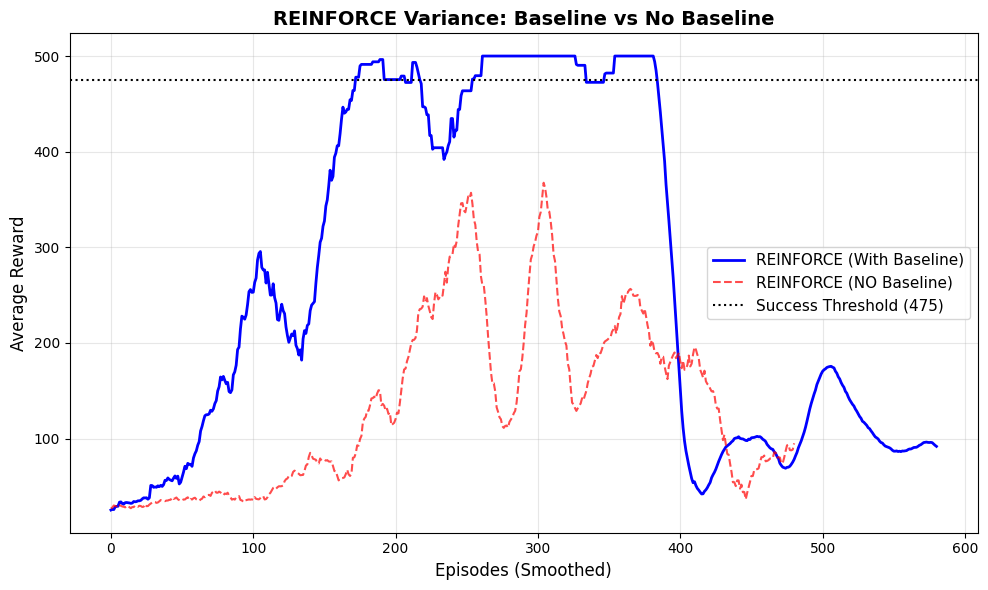


Observation for Q4: Notice how the red line (No Baseline) is much more unstable, jumps around wildly, and often takes much longer to reach the maximum score compared to the baseline version. This visually proves the variance problem!


In [32]:
# Exercise 4 Q4 — REINFORCE without baseline

# TODO: Train REINFORCEAgent with use_baseline=False
# and compare learning curve with baseline version.

# --- Q4: REINFORCE without baseline ---
print("\n" + "="*50)
print("Q4: Training REINFORCE WITHOUT baseline (High Variance)...")

# Assuming run_reinforce_training exists from Part 6
# We set use_baseline=False to see how it performs
# Use Part 6 rewards as baseline curve name expected by this cell
if 'reinforce_rewards' not in globals() and 'pg_rewards' in globals():
    reinforce_rewards = pg_rewards

# Train REINFORCE without baseline (manual loop, since run_reinforce_training has no use_baseline arg)
pg_env_no_base = gym.make('CartPole-v1')
reinforce_agent_no_base = REINFORCEAgent(
    state_dim=int(pg_env_no_base.observation_space.shape[0]),
    n_actions=int(pg_env_no_base.action_space.n),
    lr=2e-3,
    gamma=0.99,
    use_baseline=False
)

rewards_no_baseline = []
losses_no_baseline = []

n_episodes = 500
print_every = 50

for ep in range(n_episodes):
    state, _ = pg_env_no_base.reset()
    ep_states, ep_actions, ep_rewards = [], [], []

    while True:
        action = reinforce_agent_no_base.select_action(state)
        next_state, reward, terminated, truncated, _ = pg_env_no_base.step(action)

        ep_states.append(state)
        ep_actions.append(action)
        ep_rewards.append(reward)

        state = next_state
        if terminated or truncated:
            break

    loss = reinforce_agent_no_base.update(ep_states, ep_actions, ep_rewards)
    rewards_no_baseline.append(sum(ep_rewards))
    losses_no_baseline.append(loss)

    if (ep + 1) % print_every == 0:
        avg = np.mean(rewards_no_baseline[-100:])
        print(f'Ep {ep+1:4d} | Avg(100)={avg:6.1f} | Loss={loss:.4f}')

pg_env_no_base.close()

# --- Plot the comparison ---
def moving_average(data, window_size=20):
    """Calculates the moving average to smooth out the noisy RL plots."""
    if len(data) < window_size:
        return data
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

plt.figure(figsize=(10, 6))

# Assuming `reinforce_rewards` is the variable from Part 6 (REINFORCE with baseline)
# If you didn't save it, you might need to run the baseline version again here.
try:
    plt.plot(moving_average(reinforce_rewards), label='REINFORCE (With Baseline)', color='blue', linewidth=2)
except NameError:
    print("Note: Could not find 'reinforce_rewards' from Part 6 to plot the baseline comparison.")

plt.plot(moving_average(rewards_no_baseline), label='REINFORCE (NO Baseline)', color='red', alpha=0.7, linestyle='--')

plt.title('REINFORCE Variance: Baseline vs No Baseline', fontsize=14, fontweight='bold')
plt.xlabel('Episodes (Smoothed)', fontsize=12)
plt.ylabel('Average Reward', fontsize=12)
plt.axhline(y=475, color='black', linestyle=':', label='Success Threshold (475)')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nObservation for Q4: Notice how the red line (No Baseline) is much more unstable, jumps around wildly, and often takes much longer to reach the maximum score compared to the baseline version. This visually proves the variance problem!")

---
## Part 8 — Advanced Extensions (Optional)

###  Challenge 1 — Double DQN

Standard DQN overestimates Q-values because it uses the same network to select **and** evaluate the action.  
**Double DQN** decouples these:
$$\text{target} = r + \gamma Q(s', \underbrace{\arg\max_{a'} Q(s',a';\theta)}_{\text{online net selects}};\underbrace{\theta^-}_{\text{target net evaluates}})$$

Modify `_train_step` to implement Double DQN.

In [ ]:
# Challenge 1 — Double DQN target computation
# TODO: Replace the current target computation:
#   next_q = target_net(next_states)
#   target  = r + γ · max(next_q)
# With Double DQN:
#   best_actions = argmax over online_net
#   target       = r + γ · Q(s', best_actions ; θ⁻)

# (Assuming next_states, rewards, dones are already defined in cell for testing)
gamma = 0.99 

# 1. Online network selects the best action for the next state
next_q_online = online_net(next_states, training=False)
best_actions = tf.cast(tf.argmax(next_q_online, axis=1), tf.int32)

# 2. Target network evaluates the Q-values
next_q_target = target_net(next_states, training=False)

# 3. Extract the Target Network's Q-value for the action chosen by the Online Network
batch_indices = tf.range(tf.shape(next_states)[0], dtype=tf.int32)
action_indices = tf.stack([batch_indices, best_actions], axis=1)
double_q_values = tf.gather_nd(next_q_target, action_indices)

# 4. Compute the final Double DQN target
td_targets = rewards + gamma * double_q_values * (1.0 - dones)

print("Double DQN target computed successfully!")    

Double DQN target computed successfully!


In [10]:
class Double_DQNAgent:
    """
    Double Deep Q-Network agent (Double DQN).

    Key components:
        - Online network  : learns at every step AND selects next actions
        - Target network  : frozen copy, EVALUATES the actions chosen by online net
        - Replay buffer   : breaks temporal correlations
        - ε-greedy policy : balances exploration vs exploitation
    """

    def __init__(
        self,
        state_dim,
        n_actions,
        lr=1e-3,
        gamma=0.99,
        epsilon=1.0,
        epsilon_min=0.01,
        epsilon_decay=0.995,
        buffer_capacity=10_000,
        batch_size=64,
        target_update_freq=100,
    ):
        self.state_dim   = state_dim
        self.n_actions   = n_actions
        self.gamma       = gamma
        self.epsilon     = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.batch_size  = batch_size
        self.target_update_freq = target_update_freq
        self.step_count  = 0

        # Networks
        self.online_net = build_dqn(state_dim, n_actions)
        self.target_net = build_dqn(state_dim, n_actions)
        self.target_net.set_weights(self.online_net.get_weights())

        # Optimiser
        self.optimiser = keras.optimizers.Adam(learning_rate=lr)

        # Replay buffer
        self.replay_buffer = ReplayBuffer(capacity=buffer_capacity)

        # Logging
        self.losses = []

    # ----------------------------------------------------------
    def select_action(self, state, mode='train'):
        """
        ε-greedy action selection.
        """
        if mode == 'train' and np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)
        state_t = tf.convert_to_tensor(state[np.newaxis], dtype=tf.float32)
        q_vals  = self.online_net(state_t, training=False)
        return int(tf.argmax(q_vals[0]).numpy())

    # ----------------------------------------------------------
    @tf.function
    def _train_step(self, states, actions, rewards, next_states, dones):
        """
        One gradient update step using Double DQN logic.
        """
        # --- DOUBLE DQN TD targets ---
        
        # 1. Online network SELECTS best action for next state
        next_q_online = self.online_net(next_states, training=False)
        best_actions = tf.cast(tf.argmax(next_q_online, axis=1), tf.int32)
        
        # 2. Target network EVALUATES Q-values
        next_q_target = self.target_net(next_states, training=False)
        
        # 3. Extract Target Net's Q-value for the action chosen by Online Net
        batch_indices = tf.range(tf.shape(next_states)[0], dtype=tf.int32)
        action_indices = tf.stack([batch_indices, best_actions], axis=1)
        double_q_values = tf.gather_nd(next_q_target, action_indices)
        
        # 4. Compute final target
        td_targets = rewards + self.gamma * double_q_values * (1.0 - dones)

        # --- Online network gradient (unchanged) ---
        with tf.GradientTape() as tape:
            q_all  = self.online_net(states, training=True)         # (B, A)
            
            # Pick Q-value for the action actually taken
            action_idx = tf.stack(
                [tf.range(tf.shape(actions)[0]), actions], axis=1
            )
            q_taken = tf.gather_nd(q_all, action_idx)               # (B,)
            loss = tf.reduce_mean(tf.square(td_targets - q_taken))

        grads = tape.gradient(loss, self.online_net.trainable_variables)
        self.optimiser.apply_gradients(
            zip(grads, self.online_net.trainable_variables)
        )
        return loss

    # ----------------------------------------------------------
    def train_step(self, state, action, reward, next_state, done):
        """Store transition and maybe update networks."""
        self.replay_buffer.push(state, action, reward, next_state, done)
        self.step_count += 1

        if len(self.replay_buffer) < self.batch_size:
            return  # Not enough samples yet

        # Sample and train
        states, actions, rewards, next_states, dones = \
            self.replay_buffer.sample(self.batch_size)

        loss = self._train_step(
            tf.constant(states),
            tf.constant(actions),
            tf.constant(rewards),
            tf.constant(next_states),
            tf.constant(dones),
        )
        self.losses.append(float(loss))

        # Sync target network
        if self.step_count % self.target_update_freq == 0:
            self.target_net.set_weights(self.online_net.get_weights())

        # Decay exploration
        self.epsilon = max(self.epsilon_min,
                           self.epsilon * self.epsilon_decay)

print('DQNAgent class upgraded to Double DQN!')

DQNAgent class upgraded to Double DQN!


In [ ]:
def run_double_dqn_training(n_episodes=500, print_every=50):
    """Full Double DQN training loop on CartPole-v1."""

    train_env = gym.make('CartPole-v1')
    agent = Double_DQNAgent(
        state_dim   = train_env.observation_space.shape[0],
        n_actions   = train_env.action_space.n,
        lr          = 1e-3,
        gamma       = 0.99,
        epsilon     = 1.0,
        epsilon_min = 0.01,
        epsilon_decay = 0.995,
        buffer_capacity = 10_000,
        batch_size  = 64,
        target_update_freq = 100,
    )

    episode_rewards = []

    for ep in range(n_episodes):
        state, _ = train_env.reset()
        ep_reward = 0

        while True:
            action = agent.select_action(state, mode='train')
            next_state, reward, terminated, truncated, _ = train_env.step(action)
            done = terminated or truncated

            agent.train_step(state, action, reward, next_state, float(done))

            state      = next_state
            ep_reward += reward

            if done:
                break

        episode_rewards.append(ep_reward)

        if (ep + 1) % print_every == 0:
            avg = np.mean(episode_rewards[-100:])
            print(f'Ep {ep+1:4d} | Avg(100)={avg:6.1f} | ε={agent.epsilon:.3f} '
                    f'| Buffer={len(agent.replay_buffer):5d}')

    train_env.close()
    return agent, episode_rewards


Training DOUBLE DQN on CartPole-v1 ...
Ep   50 | Avg(100)=  35.0 | ε=0.010 | Buffer= 1751
Ep  100 | Avg(100)= 157.4 | ε=0.010 | Buffer=10000
Ep  150 | Avg(100)= 270.0 | ε=0.010 | Buffer=10000
Ep  200 | Avg(100)= 283.6 | ε=0.010 | Buffer=10000
Ep  250 | Avg(100)= 369.1 | ε=0.010 | Buffer=10000
Ep  300 | Avg(100)= 390.5 | ε=0.010 | Buffer=10000
Ep  350 | Avg(100)= 376.4 | ε=0.010 | Buffer=10000
Ep  400 | Avg(100)= 390.8 | ε=0.010 | Buffer=10000
Ep  450 | Avg(100)= 397.3 | ε=0.010 | Buffer=10000
Ep  500 | Avg(100)= 340.6 | ε=0.010 | Buffer=10000


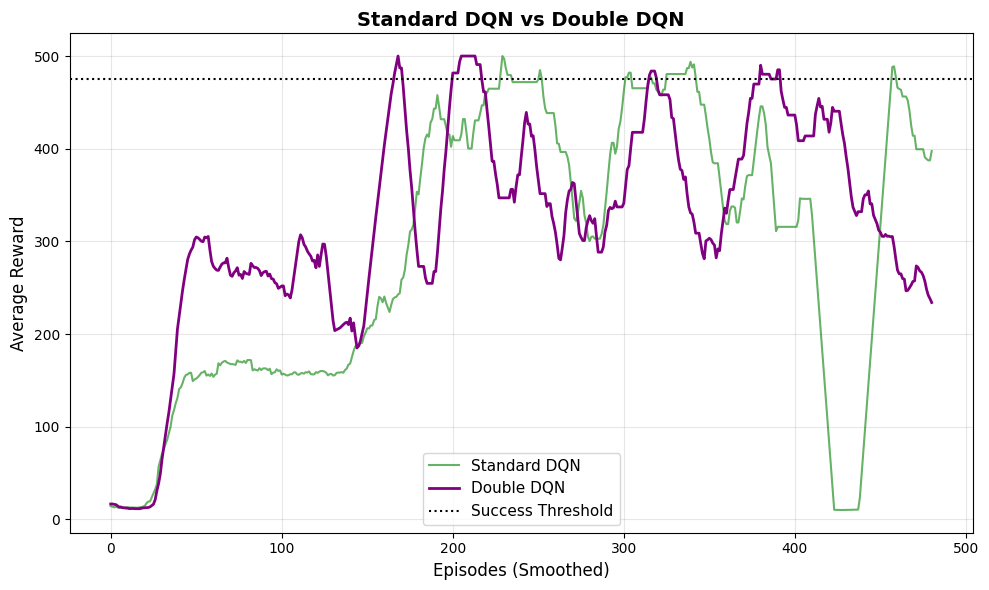

In [14]:
# 1. Run the training loop with the newly updated DQNAgent class
print('Training DOUBLE DQN on CartPole-v1 ...')
print('=' * 60)

# Notice the new variable names: ddqn_agent and ddqn_rewards
ddqn_agent, ddqn_rewards = run_double_dqn_training(n_episodes=500, print_every=50)


def moving_average(data, window_size=20):
    if len(data) < window_size: return data
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

plt.figure(figsize=(10, 6))

# Plot the original DQN from Part 4 (if it's still in your notebook's memory)
try:
    plt.plot(moving_average(dqn_rewards), label='Standard DQN', color='green', alpha=0.6)
except NameError:
    print("Standard DQN rewards not found in memory, skipping that line.")

# Plot the new Double DQN
plt.plot(moving_average(ddqn_rewards), label='Double DQN', color='purple', linewidth=2)

plt.title('Standard DQN vs Double DQN', fontsize=14, fontweight='bold')
plt.xlabel('Episodes (Smoothed)', fontsize=12)
plt.ylabel('Average Reward', fontsize=12)
plt.axhline(y=475, color='black', linestyle=':', label='Success Threshold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

###  Challenge 2 — Actor-Critic (A2C)

Actor-Critic combines the best of both worlds:
- **Actor** $\pi_\theta$: policy network (learns what action to take)
- **Critic** $V_\phi$: value network (reduces variance)

Update rule:
$$\nabla_\theta J = \mathbb{E}\left[\nabla_\theta \log\pi_\theta(a_t|s_t) \cdot \underbrace{(r_t + \gamma V_\phi(s_{t+1}) - V_\phi(s_t))}_{\text{advantage } A_t}\right]$$

**Task:** Implement a minimal A2C agent for CartPole.

In [15]:
# Challenge 2 — Minimal A2C skeleton
class A2CAgent:
    def __init__(self, state_dim, n_actions, lr=1e-3, gamma=0.99):
        # Actor network
        self.actor  = build_policy_net(state_dim, n_actions)
        # Critic network (output = single scalar V(s))
        self.critic = keras.Sequential([
            layers.Input(shape=(state_dim,)),
            layers.Dense(64, activation='relu'),
            layers.Dense(64, activation='relu'),
            layers.Dense(1),   # V(s)
        ])
        self.actor_opt  = keras.optimizers.Adam(lr)
        self.critic_opt = keras.optimizers.Adam(lr)
        self.gamma = gamma

    def update_step(self, state, action, reward, next_state, done):
        """
        One-step A2C update.

        Advantage: A = r + γV(s') - V(s)
        Actor  loss: -log π(a|s) · A
        Critic loss: (A)²
        """
        # TODO: implement the update
        state_t = tf.convert_to_tensor(state[np.newaxis], dtype=tf.float32)
        next_state_t = tf.convert_to_tensor(next_state[np.newaxis], dtype=tf.float32)
        reward_t = tf.cast(reward, tf.float32)
        done_t = tf.cast(done, tf.float32)

        with tf.GradientTape() as actor_tape, tf.GradientTape() as critic_tape:
            # 1. Critic calculations
            v_s = self.critic(state_t)[0, 0]
            v_s_next = self.critic(next_state_t)[0, 0]
            
            td_target = reward_t + self.gamma * v_s_next * (1.0 - done_t)
            advantage = td_target - v_s
            
            critic_loss = tf.square(advantage)

            # 2. Actor calculations
            action_probs = self.actor(state_t)[0]
            action_prob = action_probs[action]
            
            actor_loss = -tf.math.log(action_prob + 1e-8) * tf.stop_gradient(advantage)

        # 3. Calculate and apply gradients
        actor_grads = actor_tape.gradient(actor_loss, self.actor.trainable_variables)
        critic_grads = critic_tape.gradient(critic_loss, self.critic.trainable_variables)

        self.actor_opt.apply_gradients(zip(actor_grads, self.actor.trainable_variables))
        self.critic_opt.apply_gradients(zip(critic_grads, self.critic.trainable_variables))

print('A2C skeleton created — complete update_step as challenge exercise')

A2C skeleton created — complete update_step as challenge exercise


In [26]:
def run_a2c_training(n_episodes=500, print_every=50):
    """Full A2C training loop on CartPole-v1."""
    
    train_env = gym.make('CartPole-v1')
    
    # Initialize our dual-brained agent
    agent = A2CAgent(
        state_dim = train_env.observation_space.shape[0],
        n_actions = int(train_env.action_space.n),
        lr        = 1e-3,
        gamma     = 0.99
    )

    episode_rewards = []

    for ep in range(n_episodes):
        state, _ = train_env.reset()
        ep_reward = 0

        while True:
            # 1. Action Selection: Ask the Actor for probabilities
            state_t = tf.convert_to_tensor(state[np.newaxis], dtype=tf.float32)
            action_probs = agent.actor(state_t, training=False)[0].numpy()
            
            # Sample an action based on the probability distribution
            # FIXED: We use len(action_probs) instead of agent.n_actions
            action = np.random.choice(len(action_probs), p=action_probs)

            # 2. Step the environment
            next_state, reward, terminated, truncated, _ = train_env.step(action)
            done = terminated or truncated

            # 3. Update the agent (Actor and Critic learn together!)
            agent.update_step(state, action, reward, next_state, done)

            state      = next_state
            ep_reward += reward

            if done:
                break

        episode_rewards.append(ep_reward)

        if (ep + 1) % print_every == 0:
            avg = np.mean(episode_rewards[-100:])
            print(f'Ep {ep+1:4d} | Avg(100)={avg:6.1f}')

    train_env.close()
    return agent, episode_rewards

Training A2C on CartPole-v1 ...
Ep   50 | Avg(100)=  17.5
Ep  100 | Avg(100)=  26.2
Ep  150 | Avg(100)=  54.3
Ep  200 | Avg(100)= 124.1
Ep  250 | Avg(100)= 157.7
Ep  300 | Avg(100)=  75.2
Ep  350 | Avg(100)=   9.4
Ep  400 | Avg(100)=   9.3
Ep  450 | Avg(100)=   9.2
Ep  500 | Avg(100)=   9.3


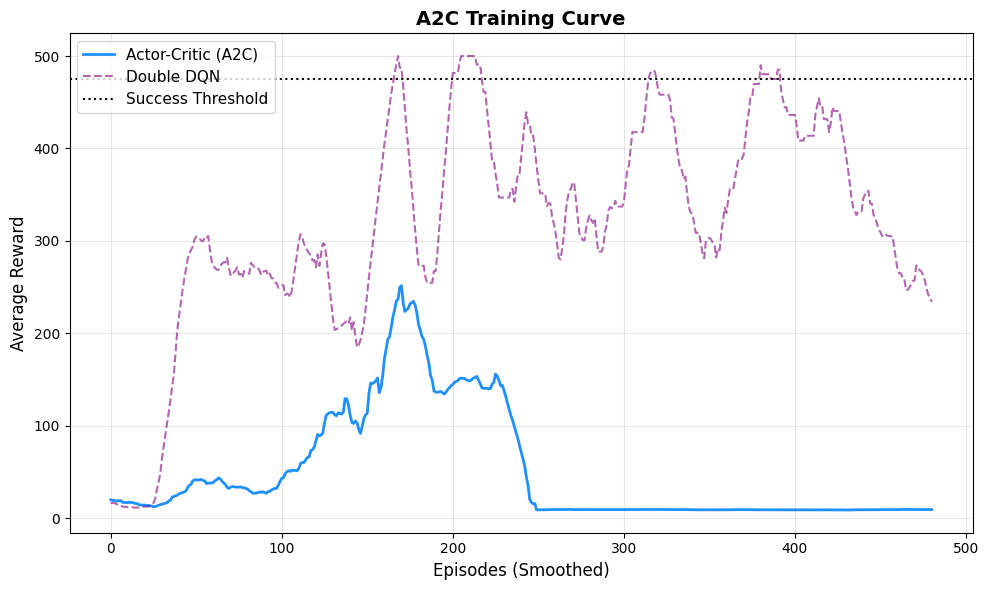

In [24]:
# --- Run the Training ---
print('Training A2C on CartPole-v1 ...')
print('=' * 60)
a2c_agent, a2c_rewards = run_a2c_training(n_episodes=500)

# --- Plot the Results ---
def moving_average(data, window_size=20):
    if len(data) < window_size: return data
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

plt.figure(figsize=(10, 6))
plt.plot(moving_average(a2c_rewards), label='Actor-Critic (A2C)', color='dodgerblue', linewidth=2)

# If you still have the Double DQN rewards in memory, you can compare them!
try:
    plt.plot(moving_average(ddqn_rewards), label='Double DQN', color='purple', alpha=0.6, linestyle='--')
except NameError:
    pass

plt.title('A2C Training Curve', fontsize=14, fontweight='bold')
plt.xlabel('Episodes (Smoothed)', fontsize=12)
plt.ylabel('Average Reward', fontsize=12)
plt.axhline(y=475, color='black', linestyle=':', label='Success Threshold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Summary & Next Week

### ✅ What You Did Today

| Component | Key Concept |
|-----------|-------------|
| Replay Buffer | Decorrelates samples, enables mini-batch updates |
| DQN | Q-Learning + neural network + replay + target net |
| REINFORCE | Direct policy optimisation, Monte-Carlo returns |
| Ablation | Each trick matters — replay > target net in practice |

### Key Takeaways

- Tabular Q-Learning **doesn't scale**; neural networks provide function approximation
- DQN's two tricks (replay + target net) solve the **stability problem**
- REINFORCE is conceptually simple but has **high variance**
- Actor-Critic bridges both worlds (next improvement)

###  Next Week — Incremental Learning

RL learns in a **single evolving task**.  
What if tasks change completely, one after another?  
→ **Catastrophic forgetting** is the new enemy.  
→ Solutions: EWC, LwF, Progressive Neural Networks.

---
*End of Lab 3*